### Link prediction baseline with common neighbour analysis: Adamic-Adar Index and Jaccard coefficient

In [21]:
import numpy as np
import random
import networkx as nx
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, roc_auc_score, average_precision_score


RANDOM_STATE = 60
random.seed(RANDOM_STATE)

In [22]:
G_karate = nx.karate_club_graph()

In [35]:
amr_layerkg = nx.read_gexf('undir_amr_KG.gexf')
wholekg = nx.read_gexf('undir_whole_KG.gexf')
host_layerkg = nx.read_gexf('undir_host_KG.gexf')
sub_cn = nx.read_gexf('subwholekg_cn.gexf')

In [36]:
def train_test_split(G,test_prop):


    test_edges = random.sample(sorted(G.edges()), int(test_prop*G.number_of_edges()))
    

    train_graph = G.copy()
    train_graph.remove_edges_from(test_edges)

    print('Number of edges for full graph:', G.number_of_edges())
    print('Number of edges held out (testing set):', len(test_edges))
    print('Number of edges for training set:', train_graph.number_of_edges())


    return test_edges, train_graph

In [37]:
def adamic_adar_predict(G_train, G_test):
    pred = list(nx.adamic_adar_index(G_train))

    pred_score_adamic, pred_label_adamic = zip(*[(s, (u,v) in G_test) for (u,v,s) in pred])

    return pred, pred_score_adamic, pred_label_adamic

In [38]:
def jaccard_predict(G_train, G_test):
    pred = list(nx.jaccard_coefficient(G_train))

    pred_score_jac, pred_label_jac = zip(*[(s, (u,v) in G_test) for (u,v,s) in pred])

    return pred, pred_score_jac, pred_label_jac

In [39]:
def auc_ap(true_label, score):
    fpr, tpr, thresholds = roc_curve(true_label,score)

    auc_score = roc_auc_score(true_label,score)

    ap_score = average_precision_score(true_label, score)

    return fpr, tpr, thresholds, auc_score, ap_score

In [40]:
def display_plot_roc(fpr_adamic,tpr_adamic,auc_adamic, ap_adamic, fpr_jac,tpr_jac,auc_jac, ap_jac):

    print(f'\n')
    print(f'AUC for Adamic-Adar index: {auc_adamic}')
    print(f'AUC for Jaccard coefficient: {auc_jac}')
    print(f'AP for Adamic-Adar index: {ap_adamic}')
    print(f'AP for Jaccard coefficient: {ap_jac}')


    plt.plot(fpr_jac,tpr_jac,'orange', label = f'Jaccard coefficient: AUC={"%.3f"%auc_jac}, AP = {"%.3f"%ap_jac}')
    plt.plot(fpr_adamic,tpr_adamic,'b', label = f'Adamic-Adar index: AUC={"%.3f"%auc_adamic}, AP = {"%.3f"%ap_adamic}')
    plt.plot(np.linspace(0,1,3),np.linspace(0,1,3),'k--')
    plt.xlabel('False postive rate')
    plt.ylabel('True positive rate')
    plt.legend(loc = 'lower right', bbox_to_anchor = (1.8,0.1))
    plt.show()

    return

In [47]:
def fullcn_pipeline(G, test_prop):

     #Step 1: Train-test split
     G_test, G_train = train_test_split(G,test_prop)

     #Step 2: Prediction
     pred_adamic, pred_score_adamic, pred_label_adamic = adamic_adar_predict(G_train, G_test)

     pred_jac, pred_score_jac, pred_label_jac = jaccard_predict(G_train, G_test)

     #Step 3: Predicition validation
     fpr_adamic, tpr_adamic, thresholds_adamic, auc_score_adamic, ap_score_adamic = auc_ap(pred_label_adamic, pred_score_adamic)

     fpr_jac, tpr_jac, thresholds_jac, auc_score_jac, ap_score_jac = auc_ap(pred_label_jac, pred_score_jac)

     #Step 4: ROC curve and metrics
     display_plot_roc(fpr_adamic,tpr_adamic,auc_score_adamic, ap_score_adamic, fpr_jac,tpr_jac,auc_score_jac, ap_score_jac)

     np.savetxt(f'results_plot/adamic_fpr.csv',fpr_adamic)
     np.savetxt(f'results_plot/adamic_tpr.csv',tpr_adamic)
     np.savetxt(f'results_plot/jac_fpr.csv',fpr_jac)
     np.savetxt(f'results_plot/jac_tpr.csv',tpr_jac)

     return G_test, pred_adamic, pred_jac
    

Number of edges for full graph: 78
Number of edges held out (testing set): 15
Number of edges for training set: 63


AUC for Adamic-Adar index: 0.6867494824016563
AUC for Jaccard coefficient: 0.568944099378882
AP for Adamic-Adar index: 0.14252224268838093
AP for Jaccard coefficient: 0.03227168563376118


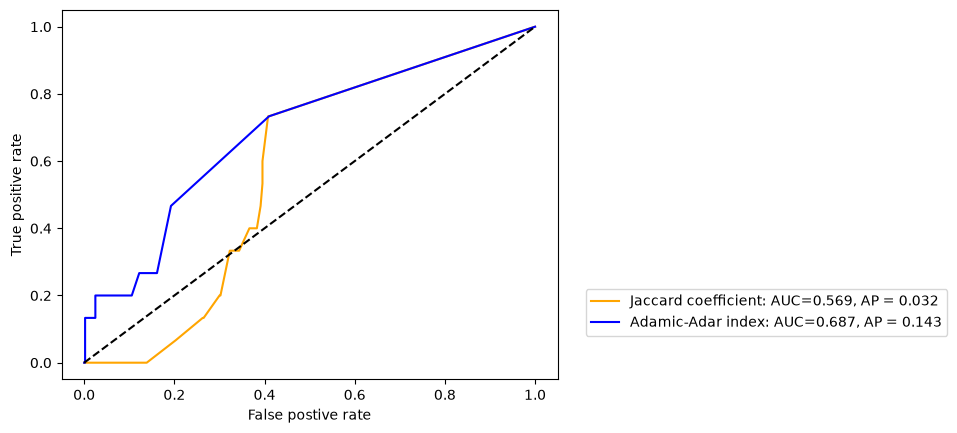

In [42]:
k_test, pred_adamic, pred_jac = fullcn_pipeline(G_karate,0.2)

Number of edges for full graph: 8923
Number of edges held out (testing set): 1784
Number of edges for training set: 7139


AUC for Adamic-Adar index: 0.4898771265194103
AUC for Jaccard coefficient: 0.3150986282295688
AP for Adamic-Adar index: 0.0023134805131593134
AP for Jaccard coefficient: 0.0004002523603147165


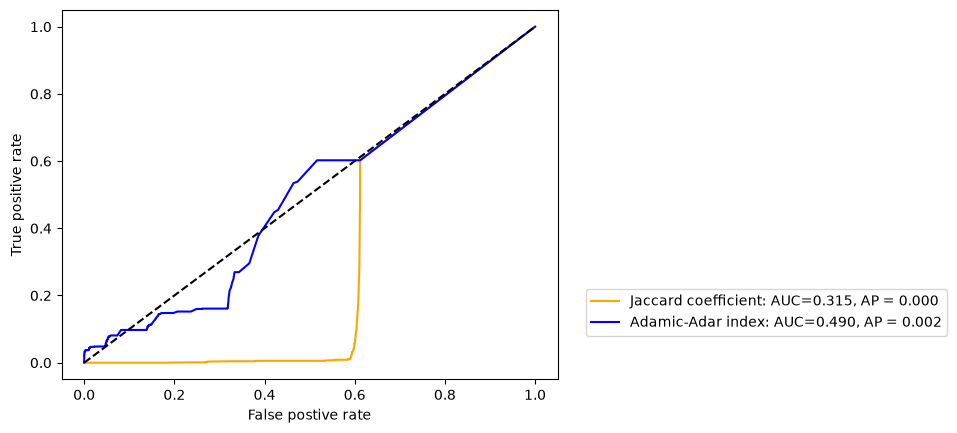

In [48]:
amr_test, amr_pred_adamic, amr_pred_jac = fullcn_pipeline(amr_layerkg,0.2)

rename saved results before running next line

Number of edges for full graph: 1196
Number of edges held out (testing set): 239
Number of edges for training set: 957




AUC for Adamic-Adar index: 0.7388881330783752
AUC for Jaccard coefficient: 0.4381232456127801
AP for Adamic-Adar index: 0.04282687379761953
AP for Jaccard coefficient: 0.0015812932892249236


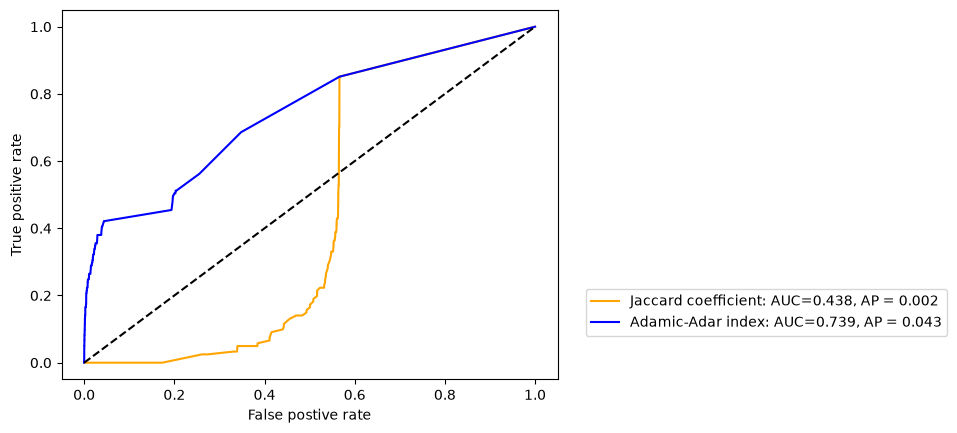

In [44]:
subwhole_test, subwhole_pred_adamic, subwhole_pred_jac = fullcn_pipeline(sub_cn,0.2)

In [45]:
#host_test, host_pred_adamic, host_pred_jac = fullcn_pipeline(host_layerkg,0.2)